# TUGAS AKHIR

* Nama: Joice Ocrisa 
* NRP: 5003221066

## Harga Saham BBRI

In [1]:
import sys
import os
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

from models.tuning_lstm import train_lstm_tuning
from models import LSTMModel, FEDformer_Model
from utils.data_loader import load_stock_data, prepare_univariate_data
from utils.evaluation import calculate_metrics, plot_predictions, plot_comparison, print_metrics


In [2]:
# Configuration 
BANK_CODE = 'BBRI'  
SEQ_LEN = 30  # Sequence length (look back period)
PRED_LEN = 1  # Prediction length
BATCH_SIZE = 32
EPOCHS = 100 
LEARNING_RATE = 0.001


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")


Using device: cpu


### Data

In [3]:
# date 
start_date = '2004-06-30'
end_date = '2025-06-30'

# get data
df = load_stock_data(BANK_CODE)
df = df[(df["Date"] >= start_date) & (df["Date"] <= end_date)]
print(f"\nUkuran data: {df.shape}")
print("Tanggal awal:", start_date)
print("Tanggal akhir:", end_date)
print("\nBerikut adalah 5 baris pertama data:")
df.head()

c:\Users\User\Documents\AA - TA\tugas-akhir\indonesia-bank-stock-dataset\datasets\BBRI\BBRI.csv

Ukuran data: (5179, 8)
Tanggal awal: 2004-06-30
Tanggal akhir: 2025-06-30

Berikut adalah 5 baris pertama data:


,Close,Date,High,Kode,Low,Nama,Open,Volume
129,152.270096,2004-06-30,152.270096,BBRI,149.997406,Bank Rakyat Indonesia (Persero,149.997406,252976869.0
130,152.270096,2004-07-01,152.270096,BBRI,147.724716,Bank Rakyat Indonesia (Persero,149.997406,239160630.0
131,156.815475,2004-07-02,156.815475,BBRI,149.997406,Bank Rakyat Indonesia (Persero,152.270096,154244664.0
132,156.815475,2004-07-05,156.815475,BBRI,156.815475,Bank Rakyat Indonesia (Persero,156.815475,0.0
133,163.633530,2004-07-06,165.906219,BBRI,156.815475,Bank Rakyat Indonesia (Persero,159.088165,533360712.0


In [4]:
# Missing Value 

missing_values = df.isnull().sum()
print(f"Missing values:\n{missing_values}")
df = df.dropna(subset=['Close'])


Missing values:
Close     0
Date      0
High      0
Kode      0
Low       0
Nama      0
Open      0
Volume    0
dtype: int64


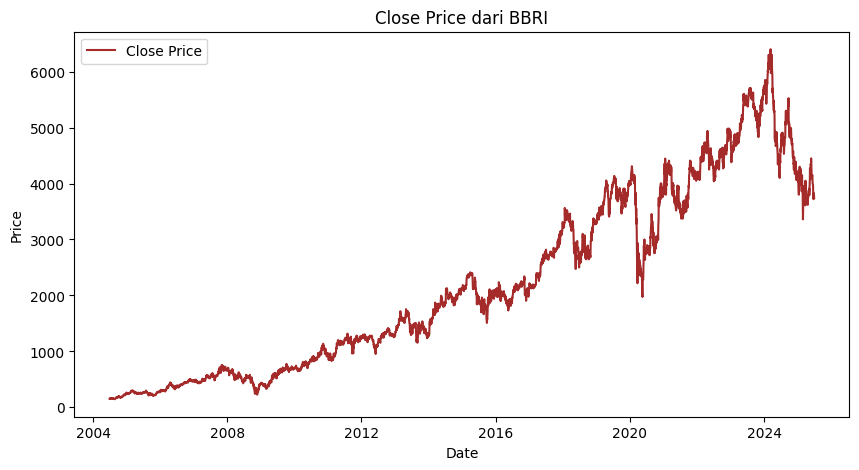

In [5]:
# Time Series Plot

plt.figure(figsize=(10, 5))
plt.plot(df['Date'], df['Close'], label = 'Close Price', color = 'brown')
plt.title('Close Price dari ' + BANK_CODE)
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [6]:
# Split Data 

X_train, y_train, X_val, y_val, X_test, y_test, scaler = prepare_univariate_data(df, feature_col='Close', seq_len=SEQ_LEN)
print(f'X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')
print(f'X_val shape: {X_val.shape}, y_val shape: {y_val.shape}')
print(f'X_test shape: {X_test.shape}, y_test shape: {y_test.shape}')

X_train shape: (3604, 30, 1), y_train shape: (3604, 1)
X_val shape: (772, 30, 1), y_val shape: (772, 1)
X_test shape: (773, 30, 1), y_test shape: (773, 1)


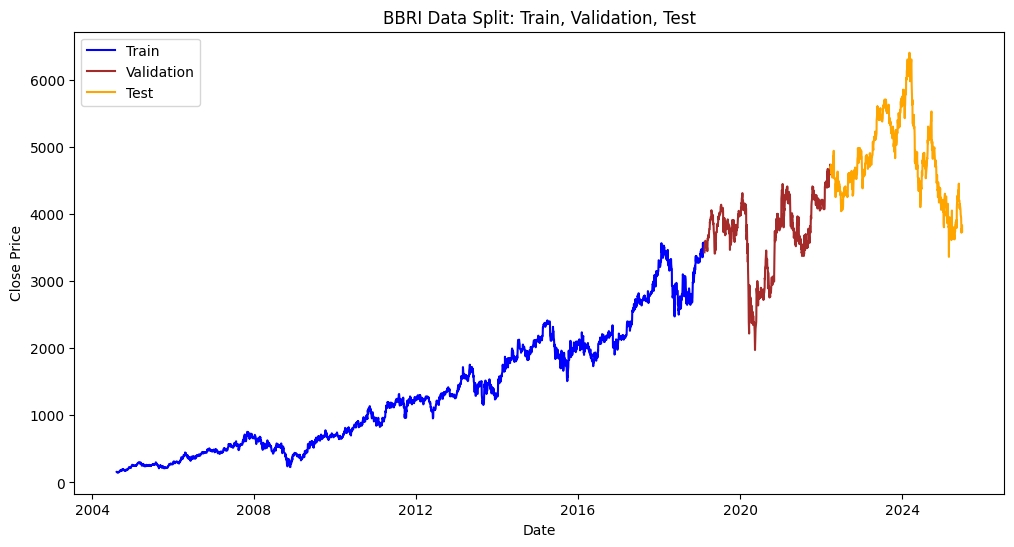

In [7]:
# Plot after split data
Train_size = len(X_train)
Val_size = len(X_val)
Test_size = len(X_test)

Date = df['Date'].values

# Define date for train val and test
idx_train_start = SEQ_LEN - 1
idx_train_end = idx_train_start + Train_size
idx_val_start = idx_train_end 
idx_val_end = idx_val_start + Val_size
idx_test_start = idx_val_end
idx_test_end = idx_test_start + Test_size

train_dates = Date[idx_train_start:idx_train_end]
val_dates = Date[idx_val_start:idx_val_end]
test_dates = Date[idx_test_start:idx_test_end]

# Ensure dates and target lengths match
target_train = y_train[:,0] if y_train.ndim > 1 else y_train
target_val = y_val[:,0] if y_val.ndim > 1 else y_val
target_test = y_test[:,0] if y_test.ndim > 1 else y_test

# Ensure target 1D for plotting
train_inv = scaler.inverse_transform(target_train.reshape(-1, 1)).flatten()
val_inv = scaler.inverse_transform(target_val.reshape(-1, 1)).flatten()
test_inv = scaler.inverse_transform(target_test.reshape(-1, 1)).flatten()

# To avoid if there is a mismatch shape
train_n = min(len(train_dates), len(train_inv))
val_n = min(len(val_dates), len(val_inv))
test_n = min(len(test_dates), len(test_inv))

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(train_dates[:train_n], train_inv[:train_n], label='Train', color='blue')
plt.plot(val_dates[:val_n], val_inv[:val_n], label='Validation', color='brown')
plt.plot(test_dates[:test_n], test_inv[:test_n], label='Test', color='orange')

plt.title(BANK_CODE + ' Data Split: Train, Validation, Test')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

In [8]:
# Buat data yang sesuai dengan Data Loader
class stockdataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = stockdataset(X_train, y_train)
val_dataset = stockdataset(X_val, y_val)    
test_dataset = stockdataset(X_test, y_test)

# Gunakan DataLoader untuk batching
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)    

## **LSTM Model**

### Train-Validation LSTM 

In [9]:
# LSTMModel 
lstm_model = LSTMModel(
    input_size = 1, 
    hidden_size=64, 
    num_layers = 2, 
    output_size = PRED_LEN, 
    dropout=0.2
).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=LEARNING_RATE)

# menurunkan learning rate secara bertahap selama training
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# training loop
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    lstm_model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        # X_batch = X_batch.to(DEVICE)
        # y_batch = y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = lstm_model(X_batch)

        loss = criterion(outputs, y_batch)
        loss.backward()

        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    
    lstm_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = lstm_model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    
    train_loss /= len(train_loader.dataset)
    val_loss /= len(val_loader.dataset)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    if (epoch+1) % 10 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/{EPOCHS}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

print("LSTM Training Complete!")

Epoch [1/100], Train Loss: 0.0065, Val Loss: 0.0013
Epoch [10/100], Train Loss: 0.0002, Val Loss: 0.0007
Epoch [20/100], Train Loss: 0.0001, Val Loss: 0.0008
Epoch [30/100], Train Loss: 0.0001, Val Loss: 0.0006
Epoch [40/100], Train Loss: 0.0001, Val Loss: 0.0003
Epoch [50/100], Train Loss: 0.0001, Val Loss: 0.0004
Epoch [60/100], Train Loss: 0.0001, Val Loss: 0.0002
Epoch [70/100], Train Loss: 0.0001, Val Loss: 0.0002
Epoch [80/100], Train Loss: 0.0000, Val Loss: 0.0003
Epoch [90/100], Train Loss: 0.0000, Val Loss: 0.0002
Epoch [100/100], Train Loss: 0.0000, Val Loss: 0.0002
LSTM Training Complete!


### Tuning Hyperparameter LSTM

In [10]:
# List Hyperparameter
dropout_list = [0.1, 0.2, 0.3]
lr_list = [1e-1, 1e-2, 1e-3]
batch_size_list = [32, 64, 128]

In [11]:
results = []

for dropout, lr, batch_size in itertools.product(
        dropout_list, lr_list, batch_size_list):

    val_loss = train_lstm_tuning(dropout, lr, batch_size, train_dataset, val_dataset, DEVICE)
    results.append({
        'dropout': dropout,
        'learning_rate': lr,
        'batch_size': batch_size,
        'val_loss': val_loss
    })
    print(f"Dropout={dropout}, LR={lr}, Batch={batch_size}, Val Loss={val_loss:.6f}")

best_config = min(results, key=lambda x: x['val_loss'])

print("\n\nBest Hyperparameter Configuration:")
print(best_config)

Dropout=0.1, LR=0.1, Batch=32, Val Loss=0.032971
Dropout=0.1, LR=0.1, Batch=64, Val Loss=0.007345
Dropout=0.1, LR=0.1, Batch=128, Val Loss=0.024052
Dropout=0.1, LR=0.01, Batch=32, Val Loss=0.037943
Dropout=0.1, LR=0.01, Batch=64, Val Loss=0.102219
Dropout=0.1, LR=0.01, Batch=128, Val Loss=0.136370
Dropout=0.1, LR=0.001, Batch=32, Val Loss=0.000848
Dropout=0.1, LR=0.001, Batch=64, Val Loss=0.000409
Dropout=0.1, LR=0.001, Batch=128, Val Loss=0.000506
Dropout=0.2, LR=0.1, Batch=32, Val Loss=0.008493
Dropout=0.2, LR=0.1, Batch=64, Val Loss=0.012779
Dropout=0.2, LR=0.1, Batch=128, Val Loss=0.015956
Dropout=0.2, LR=0.01, Batch=32, Val Loss=0.021233
Dropout=0.2, LR=0.01, Batch=64, Val Loss=0.102296
Dropout=0.2, LR=0.01, Batch=128, Val Loss=0.135888
Dropout=0.2, LR=0.001, Batch=32, Val Loss=0.000461
Dropout=0.2, LR=0.001, Batch=64, Val Loss=0.000660
Dropout=0.2, LR=0.001, Batch=128, Val Loss=0.000493
Dropout=0.3, LR=0.1, Batch=32, Val Loss=0.007430
Dropout=0.3, LR=0.1, Batch=64, Val Loss=0.017

### Training Validation with Best Hyperparameter

In [12]:
SEQ_LEN = 30  
PRED_LEN = 1  
EPOCHS = 100 
BATCH_SIZE = best_config['batch_size']
LEARNING_RATE = best_config['learning_rate']
dropout = best_config['dropout']

# LSTMModel 
lstm_model = LSTMModel(
    input_size = 1, 
    hidden_size=64, 
    num_layers = 2, 
    output_size = PRED_LEN, 
    dropout=dropout
).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# training loop
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    lstm_model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = lstm_model(X_batch)

        loss = criterion(outputs, y_batch)
        loss.backward()

        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    
    lstm_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = lstm_model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    
    train_loss /= len(train_loader.dataset)
    val_loss /= len(val_loader.dataset)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

print("LSTM Training Complete!")

Epoch [1/100] | Train Loss: 0.006974 | Val Loss: 0.001083
Epoch [2/100] | Train Loss: 0.000148 | Val Loss: 0.000773
Epoch [3/100] | Train Loss: 0.000144 | Val Loss: 0.000747
Epoch [4/100] | Train Loss: 0.000134 | Val Loss: 0.000731
Epoch [5/100] | Train Loss: 0.000157 | Val Loss: 0.000735
Epoch [6/100] | Train Loss: 0.000154 | Val Loss: 0.000690
Epoch [7/100] | Train Loss: 0.000118 | Val Loss: 0.000819
Epoch [8/100] | Train Loss: 0.000118 | Val Loss: 0.000620
Epoch [9/100] | Train Loss: 0.000120 | Val Loss: 0.000668
Epoch [10/100] | Train Loss: 0.000117 | Val Loss: 0.000608
Epoch [11/100] | Train Loss: 0.000112 | Val Loss: 0.000706
Epoch [12/100] | Train Loss: 0.000121 | Val Loss: 0.000526
Epoch [13/100] | Train Loss: 0.000118 | Val Loss: 0.000540
Epoch [14/100] | Train Loss: 0.000114 | Val Loss: 0.000514
Epoch [15/100] | Train Loss: 0.000102 | Val Loss: 0.000578
Epoch [16/100] | Train Loss: 0.000105 | Val Loss: 0.000786
Epoch [17/100] | Train Loss: 0.000113 | Val Loss: 0.000613
Epoch 

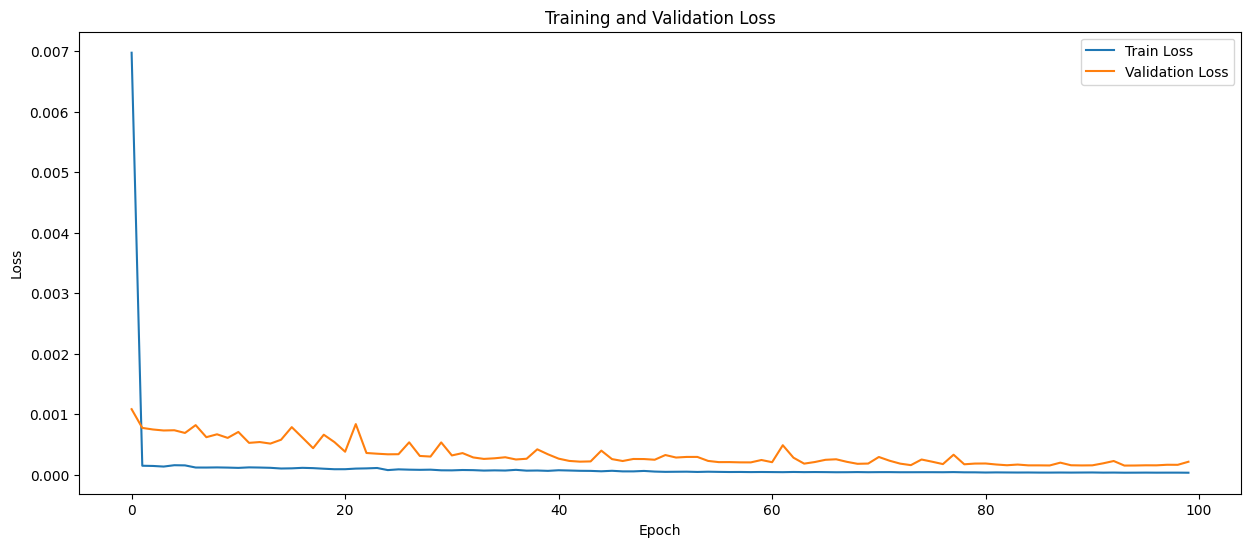

In [13]:
# Plot training and validation loss
plt.figure(figsize=(15, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [14]:
# Pengujian Model 
lstm_model.eval()

lstm_predictions = []
y_true_list = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        lstm_out = lstm_model(X_batch)
        lstm_out = lstm_out.cpu().numpy().flatten()

        lstm_predictions.append(lstm_out)
        y_true_list.append(y_batch.cpu().numpy().flatten())

lstm_pred = np.concatenate(lstm_predictions)
y_true = np.concatenate(y_true_list)

if scaler is not None:
    lstm_pred = scaler.inverse_transform(
        lstm_pred.reshape(-1, 1)
    ).flatten()

    y_true = scaler.inverse_transform(
        y_true.reshape(-1, 1)
    ).flatten()

In [15]:
# Calculate metrics
lstm_metrics = calculate_metrics(y_true, lstm_pred)

print_metrics(lstm_metrics, "LSTM")


LSTM Metrics:
----------------------------------------
MAE       : 110.1337
MSE       : 17572.6797
RMSE      : 132.5620
MAPE      : 2.2490%
R2        : 0.9517
----------------------------------------


## **FEDformer Model**

### Train-Validation FEDformer